In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import shapiro

import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('./movies_2026.csv', encoding='latin1')

In [57]:
# 1. Exploración rápida de los datos
print("Resumen del conjunto de datos:")
print("ejercicio 1 ")
print(data.info())
print("\nPrimeras filas del conjunto de datos:")
print(data.head())
print("\nEstadísticas descriptivas:")
print(data.describe(include='all'))

Resumen del conjunto de datos:
ejercicio 1 
<class 'pandas.DataFrame'>
RangeIndex: 19883 entries, 0 to 19882
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         19883 non-null  int64  
 1   budget                     19883 non-null  float64
 2   genres                     17918 non-null  str    
 3   homePage                   5607 non-null   str    
 4   productionCompany          14223 non-null  str    
 5   productionCompanyCountry   11473 non-null  str    
 6   productionCountry          16009 non-null  str    
 7   revenue                    19883 non-null  float64
 8   runtime                    19883 non-null  int64  
 9   video                      19397 non-null  object 
 10  director                   18907 non-null  str    
 11  actors                     17282 non-null  str    
 12  actorsPopularity           17275 non-null  str    
 13  actorsCharact

In [58]:
# 2. Tipo de cada variable
print("\nTipo de cada variable:")
for column in data.columns:
    if data[column].dtype == 'object':
        print(f"{column}: Cualitativa nominal")
    elif data[column].dtype in ['int64', 'float64']:
        unique_values = data[column].nunique()
        if unique_values < 10:
            print(f"{column}: Cualitativa ordinal")
        elif data[column].dtype == 'int64':
            print(f"{column}: Cuantitativa discreta")
        else:
            print(f"{column}: Cuantitativa continua")


Tipo de cada variable:
id: Cuantitativa discreta
budget: Cuantitativa continua
revenue: Cuantitativa continua
runtime: Cuantitativa discreta
video: Cualitativa nominal
popularity: Cuantitativa continua
voteAvg: Cuantitativa continua
voteCount: Cuantitativa discreta
genresAmount: Cuantitativa discreta
productionCoAmount: Cuantitativa discreta
productionCountriesAmount: Cuantitativa discreta
actorsAmount: Cuantitativa discreta
castWomenAmount: Cuantitativa continua
castMenAmount: Cuantitativa continua
releaseYear: Cuantitativa continua


In [59]:
#3.1
quantitative_columns = data.select_dtypes(include=['int64', 'float64']).columns

# Prueba de normalidad para variables cuantitativas
print("\nPrueba de normalidad para variables cuantitativas:")
normality_results = []

for column in quantitative_columns:
    stat, p_value = shapiro(data[column].dropna())
    distribution = "Normal" if p_value > 0.05 else "No Normal"
    normality_results.append({
        'Variable': column,
        'P-Value': p_value,
        'Distribución': distribution
    })
    print(f"{column}: {distribution} (p-value={p_value:.4f})")

# Mostrar resultados de normalidad en un DataFrame
normality_df = pd.DataFrame(normality_results)
print("\nResultados de la prueba de normalidad:")
print(normality_df)


Prueba de normalidad para variables cuantitativas:
id: No Normal (p-value=0.0000)
budget: No Normal (p-value=0.0000)
revenue: No Normal (p-value=0.0000)
runtime: No Normal (p-value=0.0000)
popularity: No Normal (p-value=0.0000)
voteAvg: No Normal (p-value=0.0000)
voteCount: No Normal (p-value=0.0000)
genresAmount: No Normal (p-value=0.0000)
productionCoAmount: No Normal (p-value=0.0000)
productionCountriesAmount: No Normal (p-value=0.0000)
actorsAmount: No Normal (p-value=0.0000)
castWomenAmount: No Normal (p-value=0.0000)
castMenAmount: No Normal (p-value=0.0000)
releaseYear: No Normal (p-value=0.0000)

Resultados de la prueba de normalidad:
                     Variable        P-Value Distribución
0                          id   2.892577e-95    No Normal
1                      budget  1.252443e-121    No Normal
2                     revenue  2.150795e-126    No Normal
3                     runtime   2.317679e-81    No Normal
4                  popularity  8.994243e-133    No Normal


c:\Users\Virus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 19883.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Virus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 19846.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Virus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 19721.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Virus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 19881.
  res =


Tablas de frecuencias para variables cualitativas:

Tabla de frecuencias para genres:
genres
Documentary                                    1847
Drama                                          1705
Comedy                                         1016
Horror                                          502
Animation                                       318
                                               ... 
Thriller|TV Movie|Drama                           1
Adventure|Animation|Fantasy|TV Movie|Comedy       1
Horror|Mystery|Family                             1
Drama|History|Thriller|Crime                      1
Documentary|Animation|History                     1
Name: count, Length: 2827, dtype: int64


C:\Users\Virus\AppData\Local\Temp\ipykernel_17780\1568681912.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  qualitative_columns = data.select_dtypes(include=['object']).columns


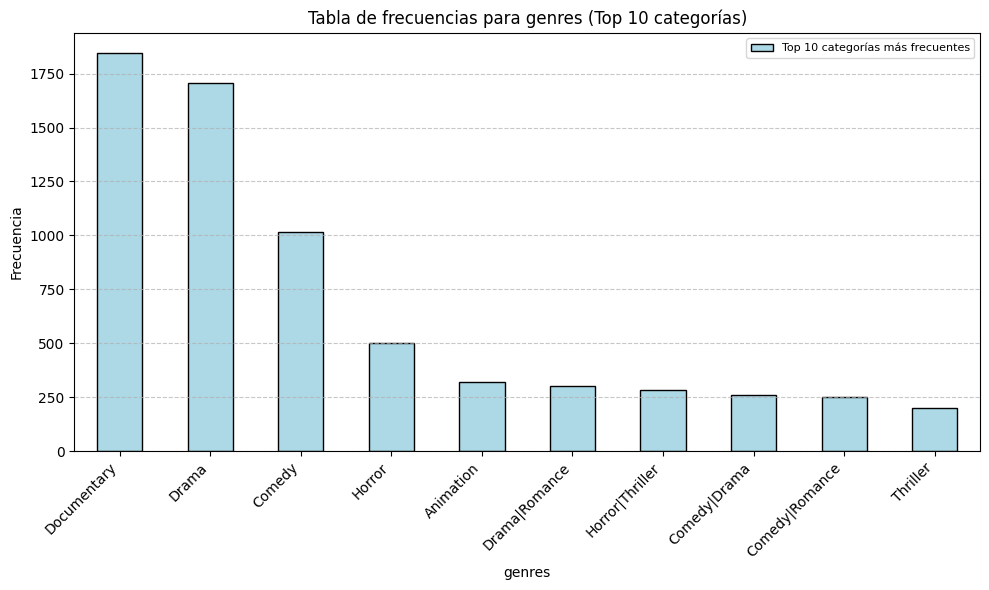


Tabla de frecuencias para homePage:
homePage
https://watch.njpwworld.com/details/60769                                                             16
https://tractorted.com/                                                                                6
http://www.naruto-movie.com/                                                                           6
http://www.avikomfilm.com                                                                              4
http://www.thehungergames.movie/                                                                       4
                                                                                                      ..
https://www.netflix.com/title/81332722                                                                 1
https://www.paramountplus.com/movies/reno-911-the-hunt-for-qanon/4lSjY6_RqRGLtpUqpgUKWtH2EFZKcmZf/     1
https://www.netflix.com/title/81478916                                                                 1
https://w

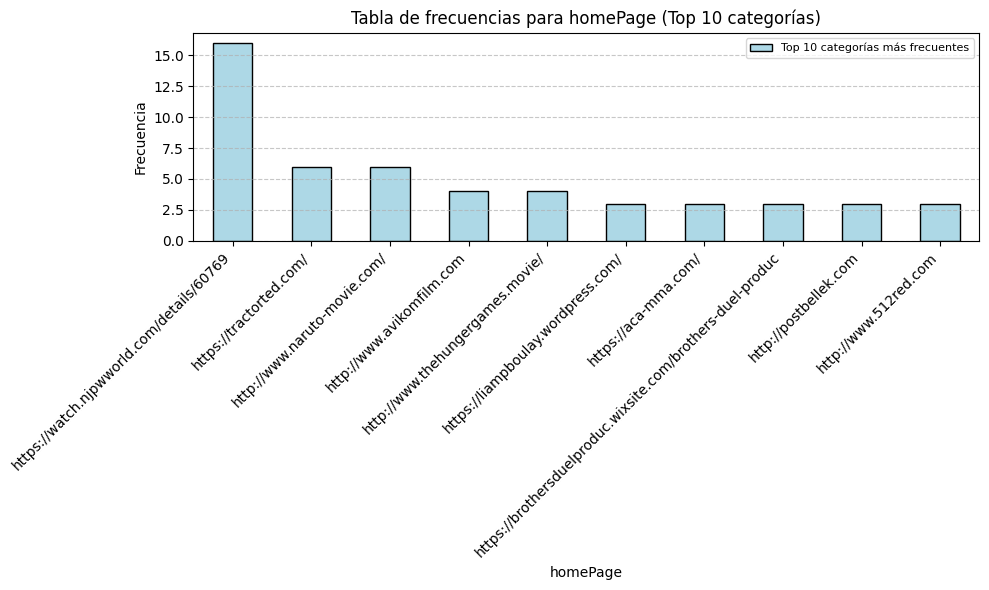


Tabla de frecuencias para productionCompany:
productionCompany
Paramount                                                   55
Universal Pictures                                          50
Warner Bros. Pictures                                       37
Toei Animation                                              36
The Asylum                                                  33
                                                            ..
Jepchu Producciones                                          1
Malvalanda                                                   1
Elefantec Global|MarVista Entertainment|Particular Crowd     1
Caracol Televisión|Dago García Producciones                  1
Central Partnership|KIT Film Studio                          1
Name: count, Length: 12232, dtype: int64


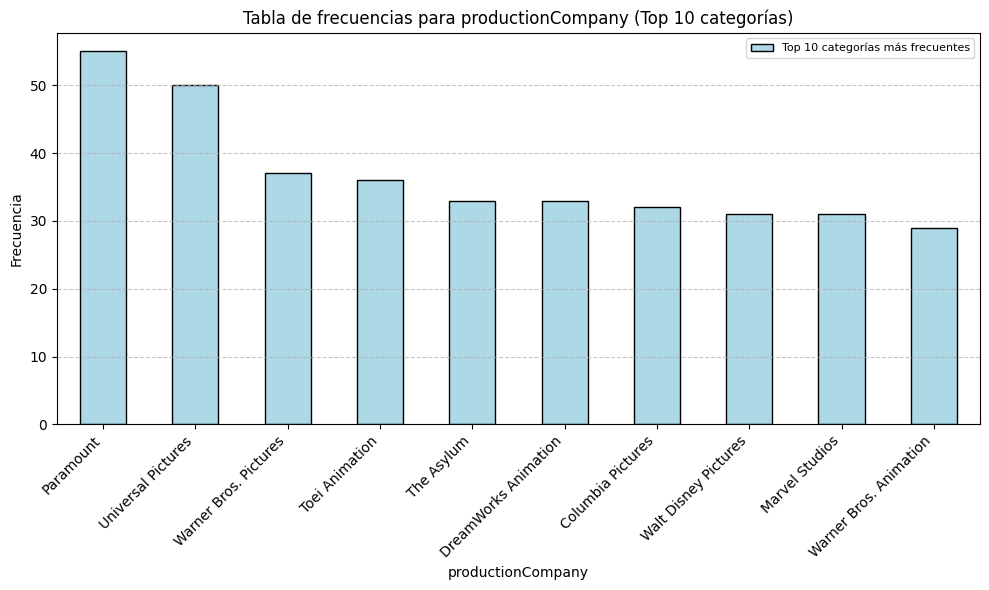


Tabla de frecuencias para productionCompanyCountry:
productionCompanyCountry
US                    1186
US|US                  833
US|US|US               474
|US                    314
|                      299
                      ... 
US|US|US|US|||||US       1
US|US|US|US|||           1
HR|HR||HR|US             1
DK|AU                    1
||BR                     1
Name: count, Length: 2744, dtype: int64


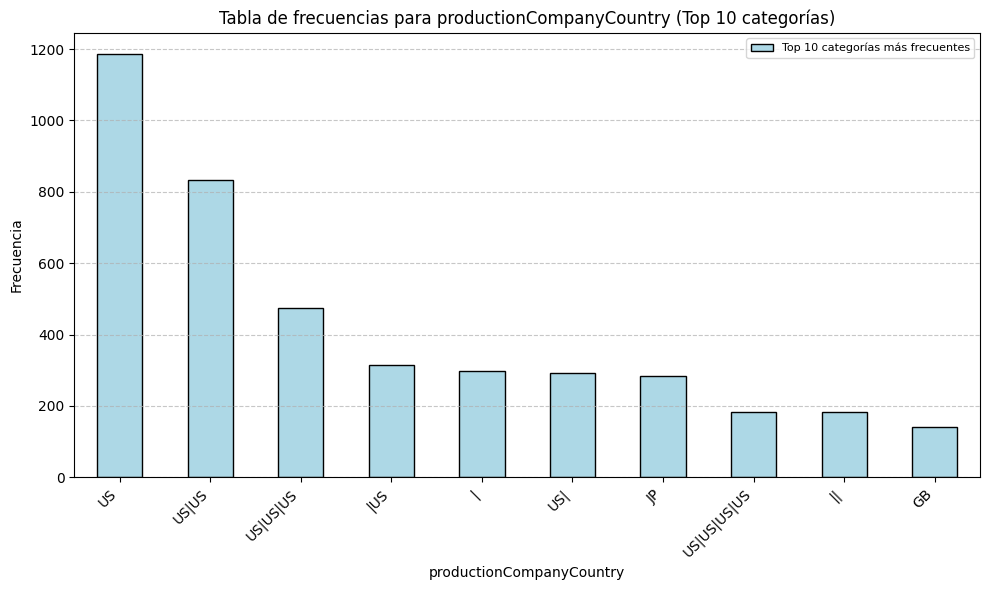


Tabla de frecuencias para productionCountry:
productionCountry
United States of America                            4968
US                                                   850
Japan                                                613
FR                                                   428
GB                                                   357
                                                    ... 
Romania|Sweden                                         1
Australia|China|Denmark|United States of America       1
Sweden|United Kingdom                                  1
Italy|Mexico                                           1
Ecuador                                                1
Name: count, Length: 1406, dtype: int64


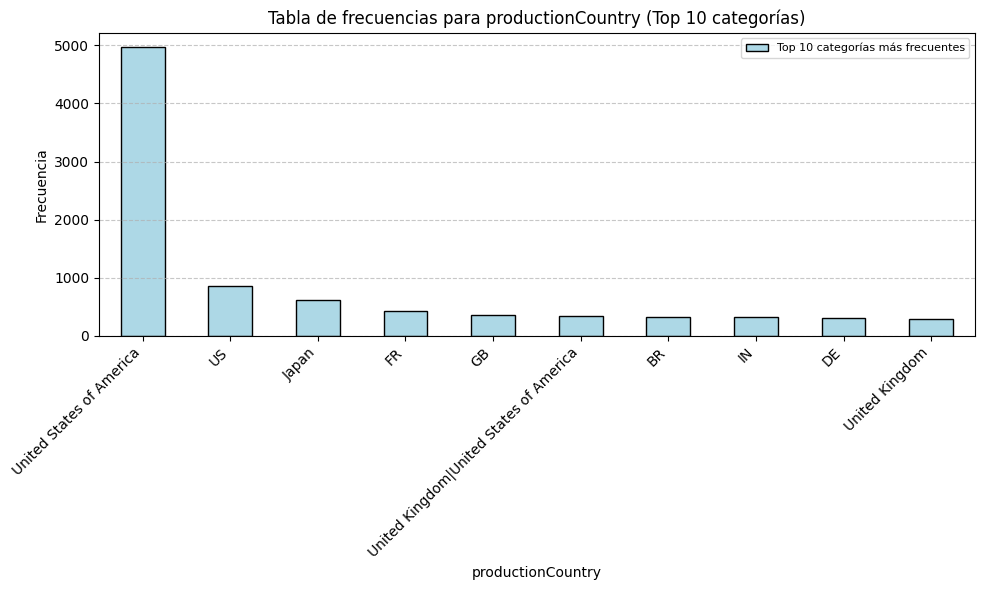


Tabla de frecuencias para video:
video
False    19313
True        84
Name: count, dtype: int64


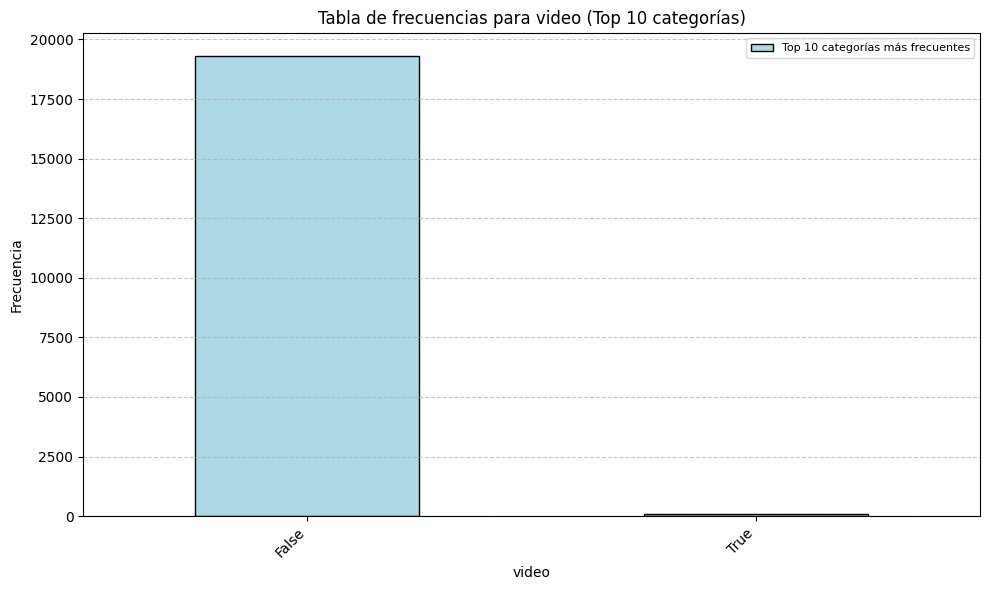


Tabla de frecuencias para director:
director
Steven Spielberg                                                                                                    29
Clint Eastwood                                                                                                      28
Ridley Scott                                                                                                        23
Martin Scorsese                                                                                                     19
Steven Soderbergh                                                                                                   19
                                                                                                                    ..
Henry Cavill|Anya Chalotra|Freya Allan|Joey Batey|Kim Bodnia|Anna Shaffer|Lauren Schmidt Hissrich|Tomek Baginski     1
Mario N. Bonassin                                                                                                    1
Ro

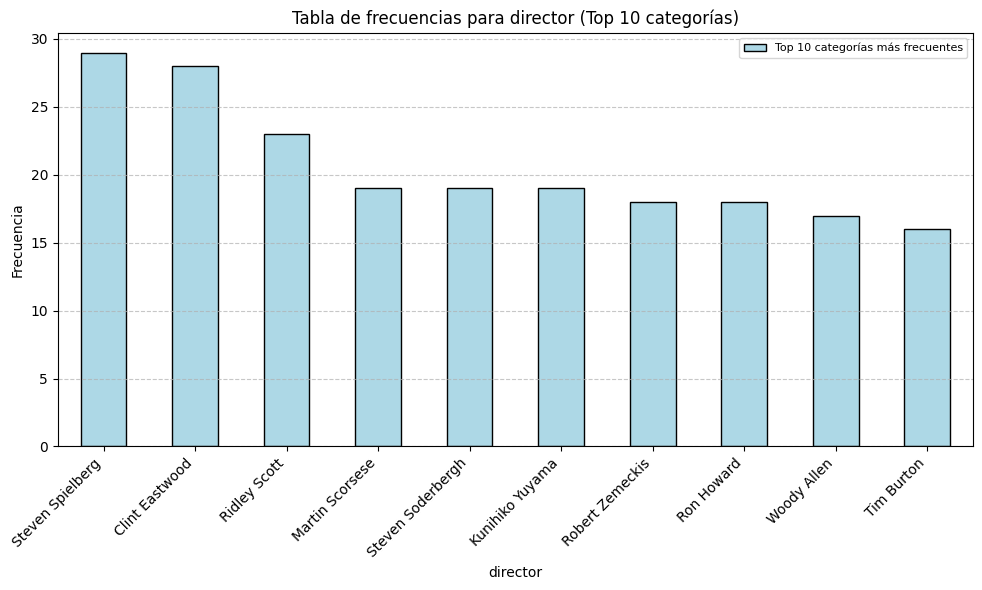


Tabla de frecuencias para actors:
actors
FALSE                                                                                                                                                                                                                                                  480
Donovan Haessy                                                                                                                                                                                                                                           6
TRUE                                                                                                                                                                                                                                                     6
Dylan Walker                                                                                                                                                                                                 

C:\Users\Virus\AppData\Local\Temp\ipykernel_17780\1568681912.py:25: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # Ajustar el diseño para evitar solapamientos
C:\Users\Virus\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


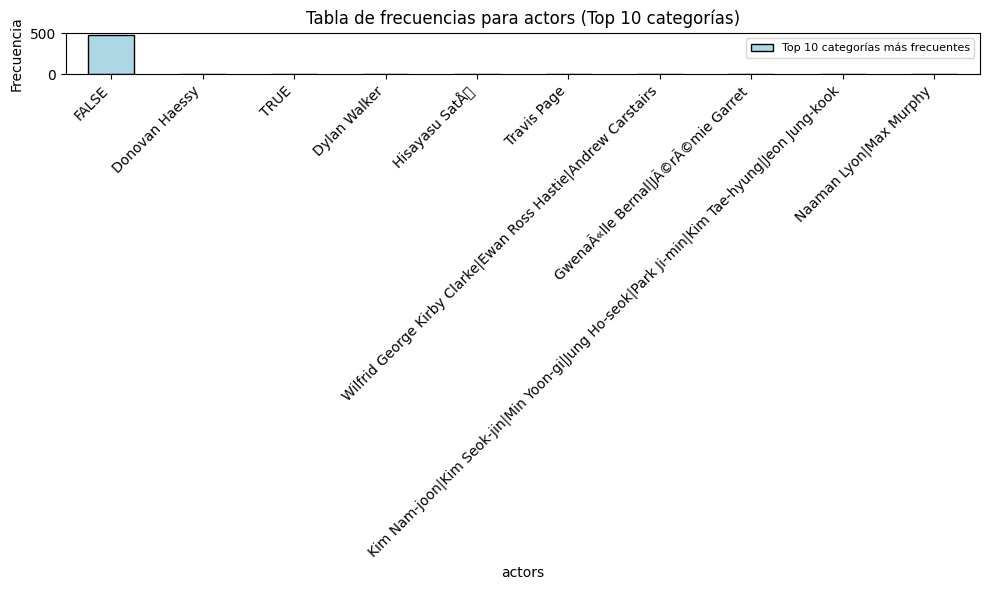


Tabla de frecuencias para actorsPopularity:
actorsPopularity
0                                                                          311
0|0                                                                        263
0|0|0                                                                      142
0.0071                                                                     133
0|0|0|0                                                                    129
                                                                          ... 
Self|Self|Self|Self|Self|Self|Self|Self                                      1
18.185|0.828|0.6|0.6|0.6|1.102|3.069|0.6|0.6|0.6                             1
1.55|0.84|0.6|0.6|0.6|0.6|0.6|0.6                                            1
0.6|0.98|0.6|0.6|0.6|0.6|0.6|0.6|1.4|0.6|0.6|1.262|0.98|0.6|0.6|0.6|0.6      1
7.402|3.103|8.74|7.158|2.951|0.6|1.214|9.197                                 1
Name: count, Length: 15134, dtype: int64


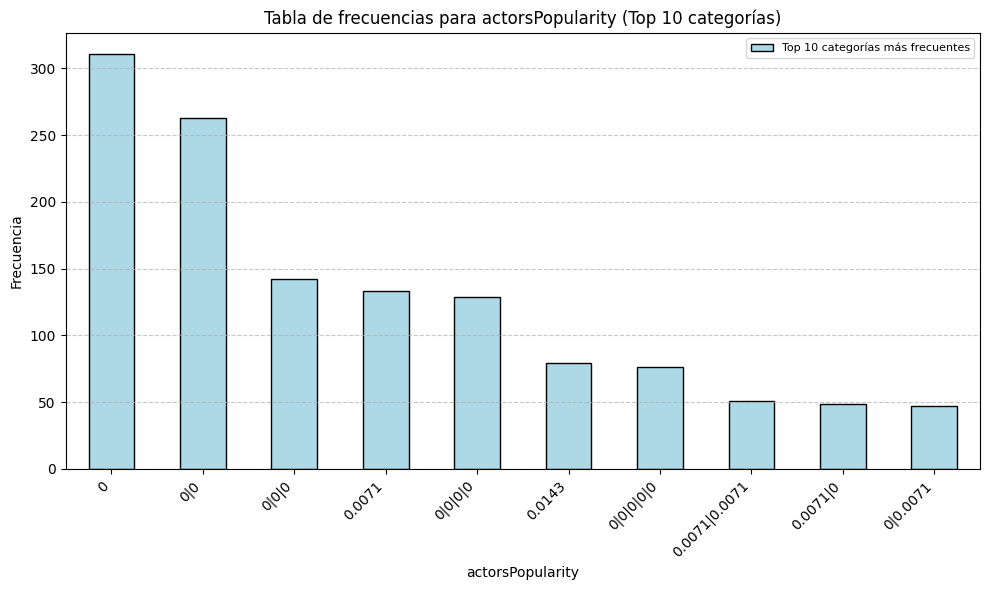


Tabla de frecuencias para actorsCharacter:
actorsCharacter
|                                                                                 233
Self                                                                              197
|||                                                                               191
|||||||||                                                                         189
||                                                                                188
                                                                                 ... 
917263                                                                              1
919590                                                                              1
Dr. Malone|Grace|Joaquin|Allison|Rex|Jason|Rita|Jake|Adam|Benji                     1
La abuela - Raquel|El papá|La mamá|Sarita|El hermano|El mexicano|Pabón|La mala      1
922162                                                                          

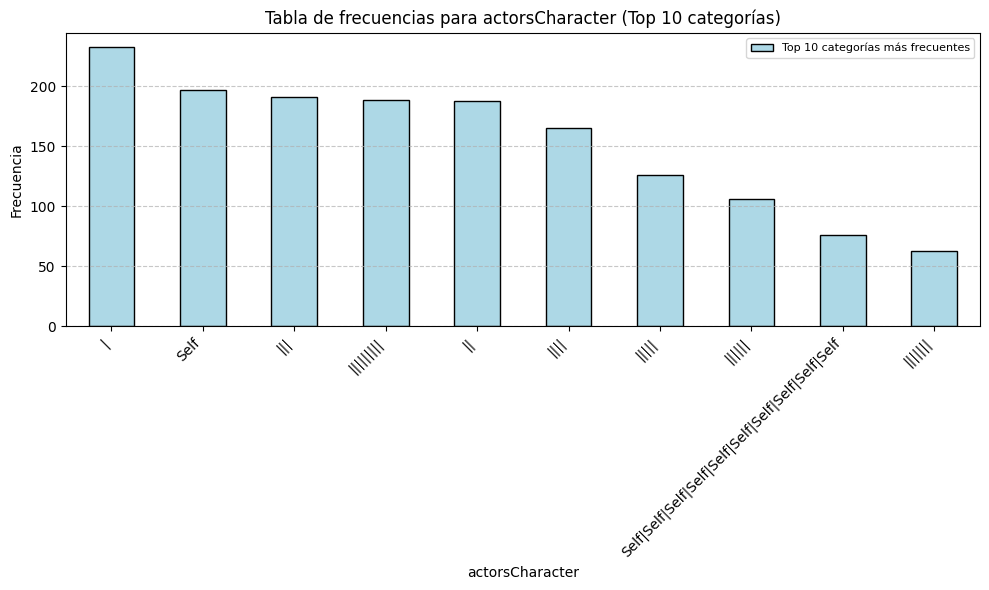


Tabla de frecuencias para originalTitle:
originalTitle
Cinderella                                                             4
Pinocchio                                                              4
Aladdin                                                                3
ç¬¬6åâãµããã¯ããªã³ã»ã¹âMax Heartãã¼ãã¡ã³ã    3
Abduction                                                              3
                                                                      ..
Megaboa                                                                1
El paseo 6                                                             1
Chief Daddy 2: Going for Broke                                         1
The Witcher: Fireplace                                                 1
Row 19                                                                 1
Name: count, Length: 19507, dtype: int64


C:\Users\Virus\AppData\Local\Temp\ipykernel_17780\1568681912.py:25: UserWarning: Glyph 155 (\x9b) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # Ajustar el diseño para evitar solapamientos
C:\Users\Virus\AppData\Local\Temp\ipykernel_17780\1568681912.py:25: UserWarning: Glyph 158 (\x9e) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # Ajustar el diseño para evitar solapamientos
C:\Users\Virus\AppData\Local\Temp\ipykernel_17780\1568681912.py:25: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # Ajustar el diseño para evitar solapamientos
C:\Users\Virus\AppData\Local\Temp\ipykernel_17780\1568681912.py:25: UserWarning: Glyph 156 (\x9c) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # Ajustar el diseño para evitar solapamientos
C:\Users\Virus\AppData\Local\Temp\ipykernel_17780\1568681912.py:25: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # Ajustar el diseño para evitar solapamientos


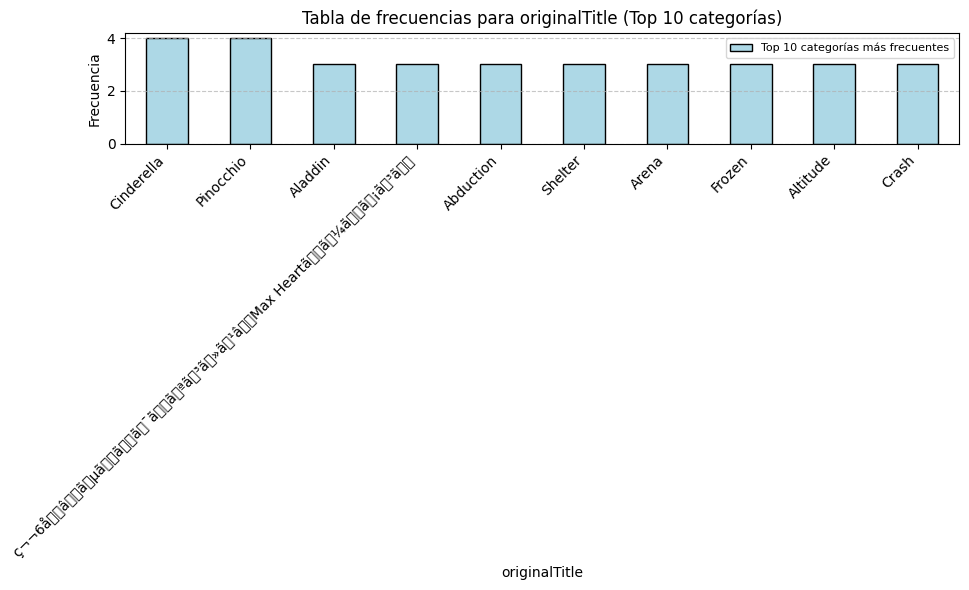


Tabla de frecuencias para title:
title
Cinderella                        5
Pinocchio                         4
Aladdin                           3
Room                              3
Abduction                         3
                                 ..
Megaboa                           1
El Paseo 6                        1
Chief Daddy 2: Going for Broke    1
The Witcher: Fireplace            1
Row 19                            1
Name: count, Length: 19385, dtype: int64


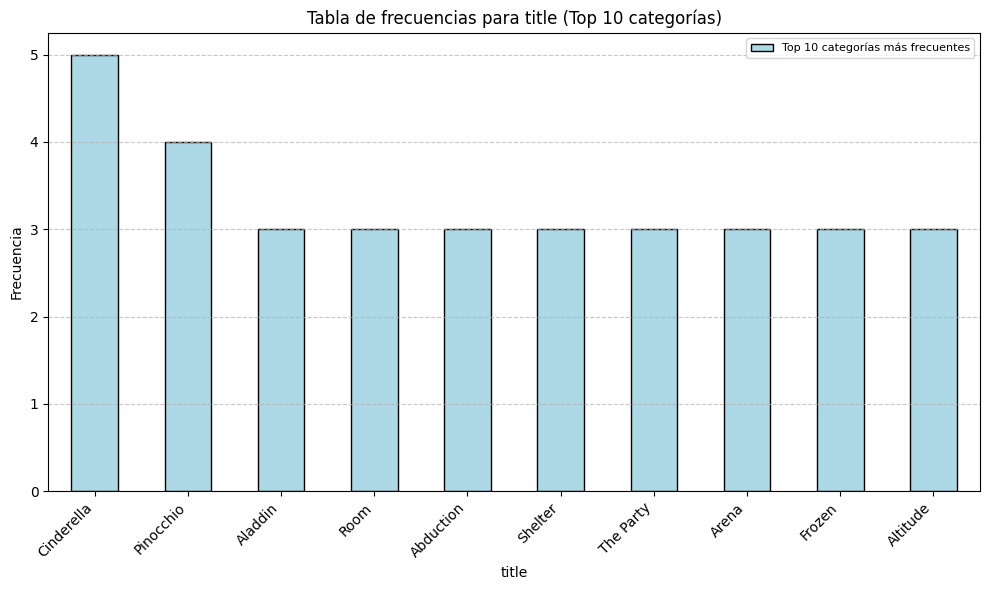


Tabla de frecuencias para originalLanguage:
originalLanguage
en    11961
es     1238
fr     1094
ja      868
pt      628
      ...  
qu        1
sw        1
be        1
mo        1
la        1
Name: count, Length: 94, dtype: int64


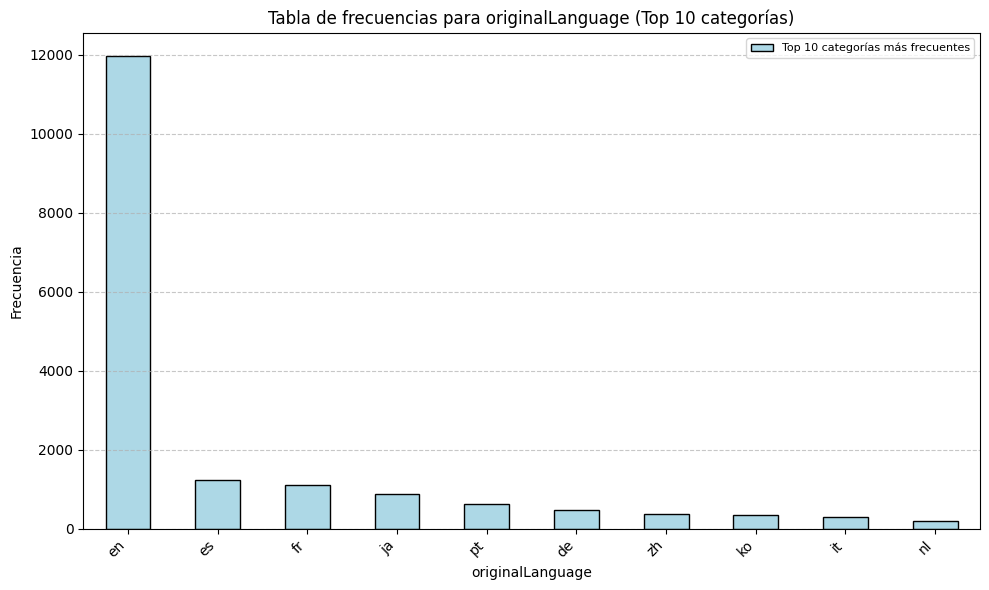


Tabla de frecuencias para releaseDate:
releaseDate
2026-01-30    263
2025-11-07    258
2025-11-08    239
2025-12-05    231
2025-11-20    225
             ... 
2021-12-27      1
2014-01-03      1
2013-06-13      1
2021-12-11      1
2021-10-31      1
Name: count, Length: 5663, dtype: int64


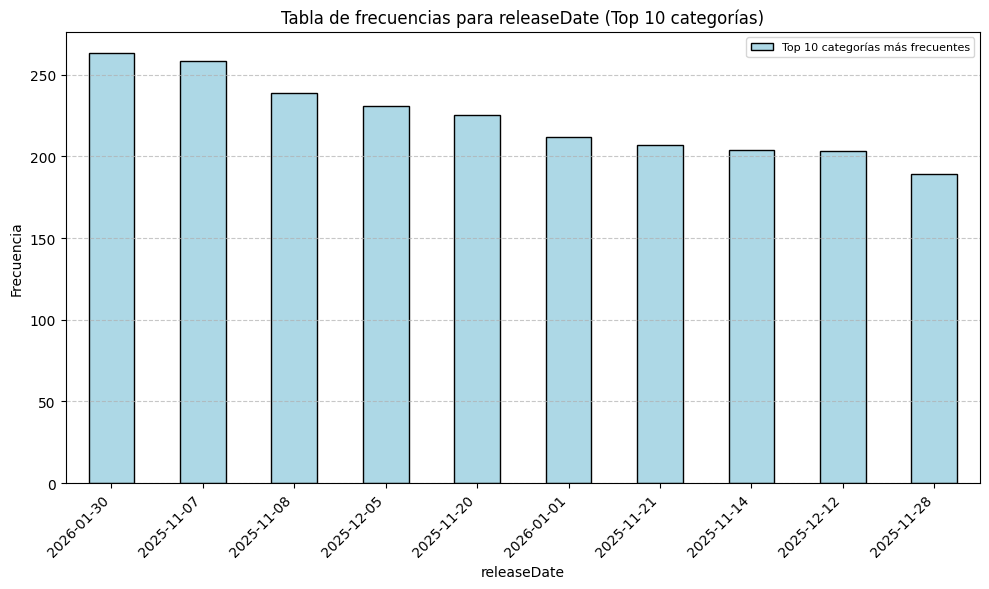

In [60]:
#3.2


# Identificar variables cualitativas
qualitative_columns = data.select_dtypes(include=['object']).columns

# Tablas de frecuencias para variables cualitativas
print("\nTablas de frecuencias para variables cualitativas:")
for column in qualitative_columns:
    frequency_table = data[column].value_counts()
    print(f"\nTabla de frecuencias para {column}:")
    print(frequency_table)

    # Seleccionar las 10 categorías más frecuentes para graficar
    top_n = 10  # Cambia este valor si quieres mostrar más o menos categorías
    top_categories = frequency_table.head(top_n)

    # Crear gráfico de barras para las categorías más frecuentes
    plt.figure(figsize=(10, 6))
    top_categories.plot(kind='bar', color='lightblue', edgecolor='black')
    plt.title(f'Tabla de frecuencias para {column} (Top {top_n} categorías)')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje X
    plt.tight_layout()  # Ajustar el diseño para evitar solapamientos
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Agregar leyenda
    plt.legend([f"Top {top_n} categorías más frecuentes"], loc='upper right', fontsize=8)

    plt.show()

In [61]:
df = pd.read_csv("movies_2026.csv", encoding="latin1")
df["releaseDate"] = pd.to_datetime(df["releaseDate"], errors="coerce")
df["main_genre"] = df["genres"].str.split("|").str[0]


In [62]:
df_ingresos = df[df["revenue"] > 0]
df_presupuesto = df[df["budget"] > 0]
df_finanzas = df[(df["budget"] > 0) & (df["revenue"] > 0)]


In [63]:
top10_presupuesto = (
    df_presupuesto[["title", "budget"]]
    .sort_values(by="budget", ascending=False)
    .head(10)
)

display(top10_presupuesto)
tabla_frecuencia_41 = (
    top10_presupuesto["title"]
    .value_counts()
    .reset_index()
)

tabla_frecuencia_41.columns = ["Película", "Frecuencia"]
tabla_frecuencia_41



,title,budget
10606,Pirates of the Caribbean: On Stranger Tides,380000000.0
14600,Avengers: Age of Ultron,365000000.0
15842,Avengers: Endgame,356000000.0
5907,Avatar: Fire and Ash,350000000.0
15843,Avengers: Infinity War,300000000.0
10053,Pirates of the Caribbean: At World's End,300000000.0
14843,Justice League,300000000.0
10497,Superman Returns,270000000.0
17024,The Lion King,260000000.0
13681,Tangled,260000000.0


,Película,Frecuencia
0,Pirates of the Caribbean: On Stranger Tides,1
1,Avengers: Age of Ultron,1
2,Avengers: Endgame,1
3,Avatar: Fire and Ash,1
4,Avengers: Infinity War,1
5,Pirates of the Caribbean: At World's End,1
6,Justice League,1
7,Superman Returns,1
8,The Lion King,1
9,Tangled,1


In [64]:
import pandas as pd
top10_ingresos = (
    df[["title", "revenue"]]
    .sort_values(by="revenue", ascending=False)
    .head(10)
)

top10_ingresos

,title,revenue
13100,Avatar,2.847246e+09
15842,Avengers: Endgame,2.797801e+09
10197,Titanic,2.187464e+09
14837,Star Wars: The Force Awakens,2.068224e+09
15843,Avengers: Infinity War,2.046240e+09
8481,Zootopia 2,1.744338e+09
14804,Jurassic World,1.671713e+09
17024,The Lion King,1.667635e+09
18937,Spider-Man: No Way Home,1.631853e+09
13287,The Avengers,1.518816e+09


In [65]:
pelicula_mas_votos = df.loc[
    df["voteCount"].idxmax(),
    ["title", "voteCount"]
]

pelicula_mas_votos

title        Inception
voteCount        30788
Name: 13401, dtype: object

In [66]:
peor_pelicula = (
    df[df["voteCount"] > 0]
    .sort_values(by="voteAvg")
    .head(1)[["title", "voteAvg"]]
)

peor_pelicula

,title,voteAvg
5303,Jingle Bell Wedding,0.0


In [67]:
df["releaseDate"] = pd.to_datetime(df["releaseDate"], errors="coerce")
df["main_genre"] = df["genres"].str.split("|").str[0]
top20_recientes = (
    df.sort_values(by="releaseDate", ascending=False)
    .head(20)[["title", "releaseDate", "main_genre"]]
)

top20_recientes

,title,releaseDate,main_genre
488,A Fading Man,2026-05-07,Drama
7895,Elon Musk Unveiled â The Tesla Experiment,2026-03-12,Documentary
4054,Skunk,2026-02-25,NaN
4760,Anastasia,2026-02-25,NaN
6897,Nikki hako no koi,2026-02-06,NaN
0,Immersed,2026-02-01,Drama
44,You Just Watch & See,2026-02-01,NaN
49,Waves Turn,2026-02-01,Documentary
48,Three Ways of Returning,2026-02-01,NaN
47,AGOS-TONO,2026-02-01,Music


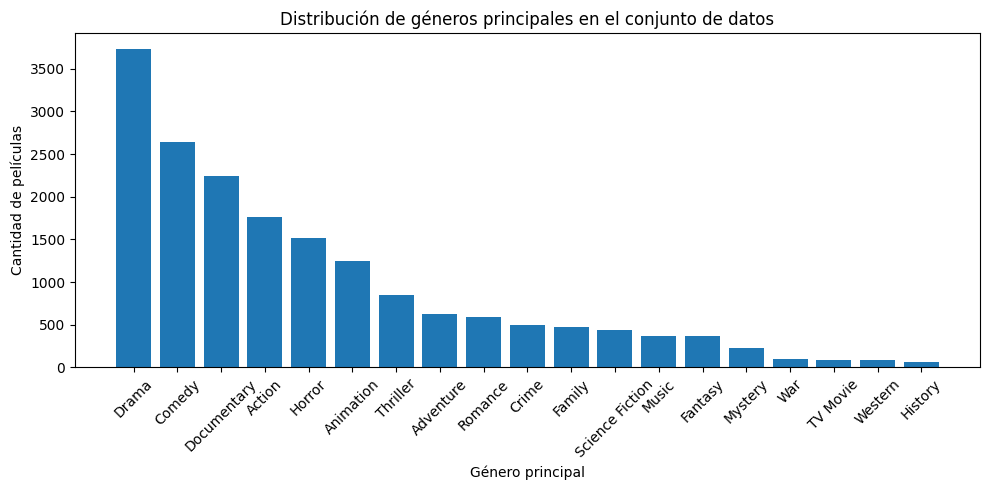

In [68]:
frecuencia_generos = (
    df["main_genre"]
    .value_counts()
    .reset_index()
)

frecuencia_generos.columns = ["Género principal", "Cantidad de películas"]

frecuencia_generos

frecuencia_generos.head(1)

plt.figure(figsize=(10, 5))
plt.bar(
    frecuencia_generos["Género principal"],
    frecuencia_generos["Cantidad de películas"]
)

plt.xlabel("Género principal")
plt.ylabel("Cantidad de películas")
plt.title("Distribución de géneros principales en el conjunto de datos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [69]:
ingresos_por_genero = (
    df_ingresos
    .groupby("main_genre")["revenue"]
    .mean()
    .reset_index()
    .sort_values(by="revenue", ascending=False)
)

ingresos_por_genero.columns = ["Género principal", "Ingresos promedio"]

display(ingresos_por_genero)


,Género principal,Ingresos promedio
1,Adventure,2.194257e+08
2,Animation,1.693564e+08
14,Science Fiction,1.689934e+08
7,Family,1.640919e+08
0,Action,1.594615e+08
8,Fantasy,1.492534e+08
16,War,1.051353e+08
9,History,8.265835e+07
3,Comedy,7.939863e+07
11,Music,7.595241e+07


In [70]:
# Relación entre cantidad de actores e ingresos 4.8
df[df["revenue"] > 0][["actorsAmount", "revenue"]].corr()


,actorsAmount,revenue
actorsAmount,1.000000,-0.001665
revenue,-0.001665,1.000000


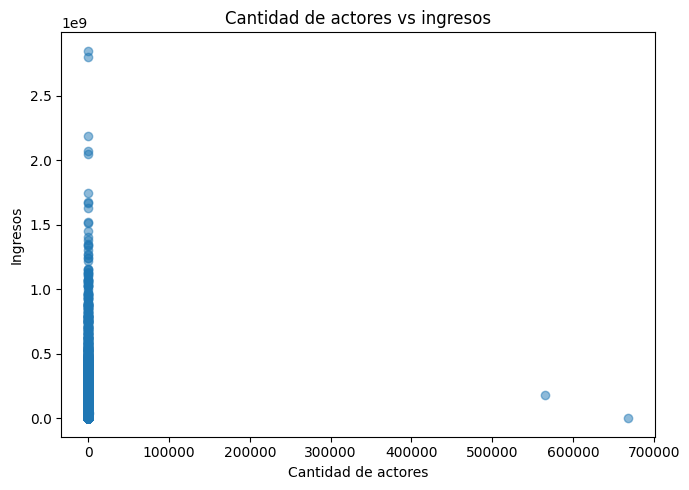

In [71]:
# Diagrama de dispersión
plt.figure(figsize=(7, 5))
plt.scatter(
    df[df["revenue"] > 0]["actorsAmount"],
    df[df["revenue"] > 0]["revenue"],
    alpha=0.5
)
plt.xlabel("Cantidad de actores")
plt.ylabel("Ingresos")
plt.title("Cantidad de actores vs ingresos")
plt.tight_layout()
plt.show()


In [72]:
# Evolución del número promedio de actores por año
df.groupby("releaseYear")["actorsAmount"].mean()


releaseYear
1902.0      11.000000
1920.0      11.000000
1921.0      35.000000
1922.0      20.000000
1925.0      31.500000
             ...     
2020.0    2842.930320
2021.0    3196.342752
2022.0      12.142857
2025.0       3.751734
2026.0       4.020891
Name: actorsAmount, Length: 101, dtype: float64

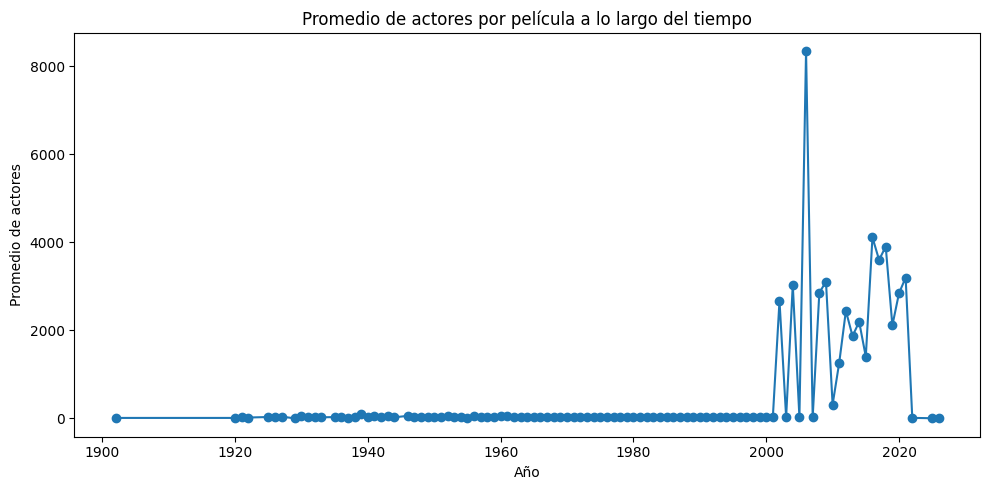

In [73]:
# Gráfico de evoluciónde número de actores
plt.figure(figsize=(10, 5))
plt.plot(
    df.groupby("releaseYear")["actorsAmount"].mean().index,
    df.groupby("releaseYear")["actorsAmount"].mean().values,
    marker="o"
)
plt.xlabel("Año")
plt.ylabel("Promedio de actores")
plt.title("Promedio de actores por película a lo largo del tiempo")
plt.tight_layout()
plt.show()


In [74]:
#4.9
df_genero_elenco = df[
    (df["revenue"] > 0) &
    df["castWomenAmount"].notna() &
    df["castMenAmount"].notna()
][["castWomenAmount", "castMenAmount", "popularity", "revenue"]]
df_genero_elenco.corr()

,castWomenAmount,castMenAmount,popularity,revenue
castWomenAmount,1.000000,-0.00636,0.050581,0.250276
castMenAmount,-0.006360,1.00000,-0.003180,0.017820
popularity,0.050581,-0.00318,1.000000,0.178880
revenue,0.250276,0.01782,0.178880,1.000000


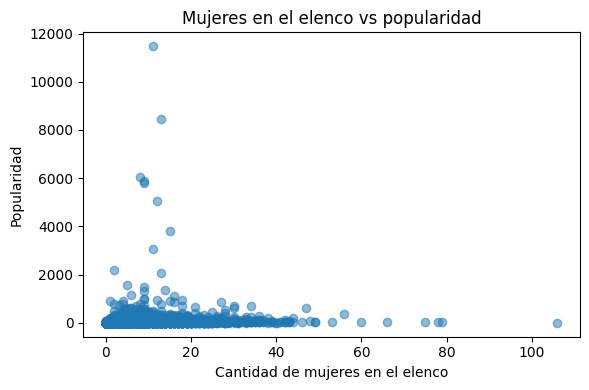

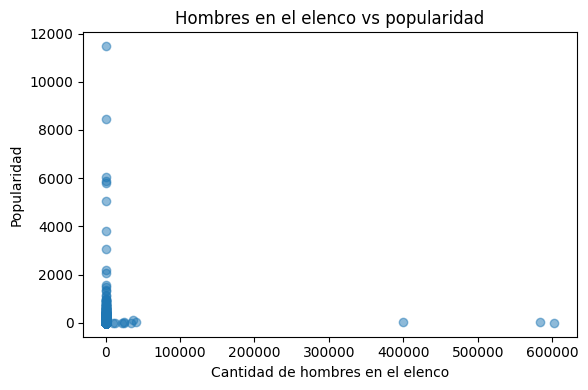

In [75]:
# Dispersión: mujeres vs popularidad
plt.figure(figsize=(6, 4))
plt.scatter(df_genero_elenco["castWomenAmount"], df_genero_elenco["popularity"], alpha=0.5)
plt.xlabel("Cantidad de mujeres en el elenco")
plt.ylabel("Popularidad")
plt.title("Mujeres en el elenco vs popularidad")
plt.tight_layout()
plt.show()
# Dispersión: hombres vs popularidad
plt.figure(figsize=(6, 4))
plt.scatter(df_genero_elenco["castMenAmount"], df_genero_elenco["popularity"], alpha=0.5)
plt.xlabel("Cantidad de hombres en el elenco")
plt.ylabel("Popularidad")
plt.title("Hombres en el elenco vs popularidad")
plt.tight_layout()
plt.show()


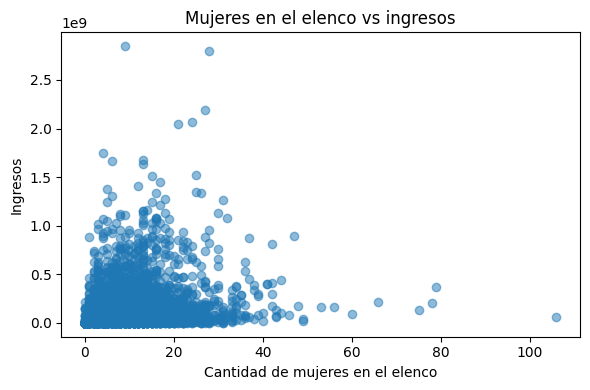

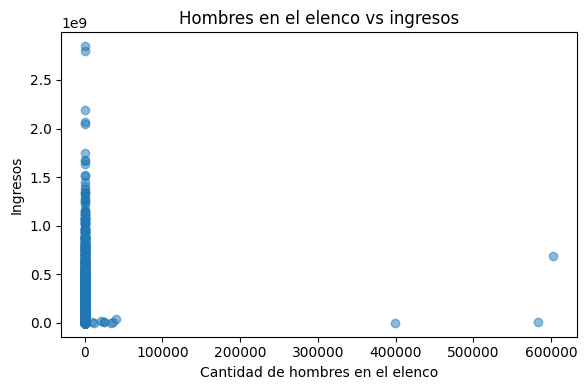

In [76]:
# Dispersión: mujeres vs ingresos
plt.figure(figsize=(6, 4))
plt.scatter(df_genero_elenco["castWomenAmount"], df_genero_elenco["revenue"], alpha=0.5)
plt.xlabel("Cantidad de mujeres en el elenco")
plt.ylabel("Ingresos")
plt.title("Mujeres en el elenco vs ingresos")
plt.tight_layout()
plt.show()
# Dispersión: hombres vs ingresos
plt.figure(figsize=(6, 4))
plt.scatter(df_genero_elenco["castMenAmount"], df_genero_elenco["revenue"], alpha=0.5)
plt.xlabel("Cantidad de hombres en el elenco")
plt.ylabel("Ingresos")
plt.title("Hombres en el elenco vs ingresos")
plt.tight_layout()
plt.show()


In [77]:
# Top 20 películas mejor calificadas 4.10
top20_mejor_calificadas = (
    df[df["voteCount"] > 0]
    .sort_values(by="voteAvg", ascending=False)
    .head(20)[["title", "director", "voteAvg"]]
)

top20_mejor_calificadas


,title,director,voteAvg
16,Crocodile Dose,Jason Waters,10.0
66,The Exchange,Fischer Sawatzky,10.0
79,AdiÃ³s Para Nunca,Daniela Vidovich,10.0
19873,Los Vengadores Chiflados,Miguel Angel Zavala,10.0
266,Regarde toi,SÃ©o Patois|Lorraine Jacques,10.0
248,Orphen,Joe Arodann|AnaÃ¯s Richerand,10.0
247,Satiata,Cyprien Klein,10.0
235,Le Moment sera le Bon,Guillaume Huss Seewald,10.0
97,GO TO SLEEP,Tirion Liddell,10.0
19234,How Ponyo was Born ~Hayao Miyazaki's Thought P...,Kaku Arakawa,10.0


In [78]:
#4.11
df_presupuesto_ingresos = df[(df["budget"] > 0) & (df["revenue"] > 0)][["budget", "revenue"]]
df_presupuesto_ingresos.corr()


,budget,revenue
budget,1.000000,0.722851
revenue,0.722851,1.000000


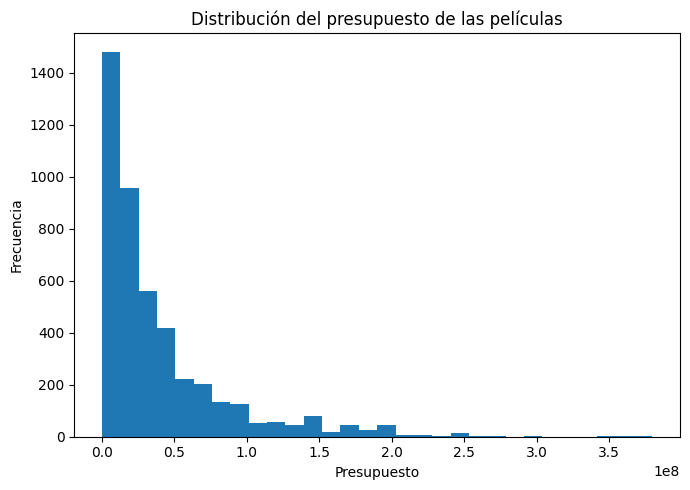

In [79]:

plt.figure(figsize=(7, 5))
plt.hist(df_presupuesto_ingresos["budget"], bins=30)
plt.xlabel("Presupuesto")
plt.ylabel("Frecuencia")
plt.title("Distribución del presupuesto de las películas")
plt.tight_layout()
plt.show()


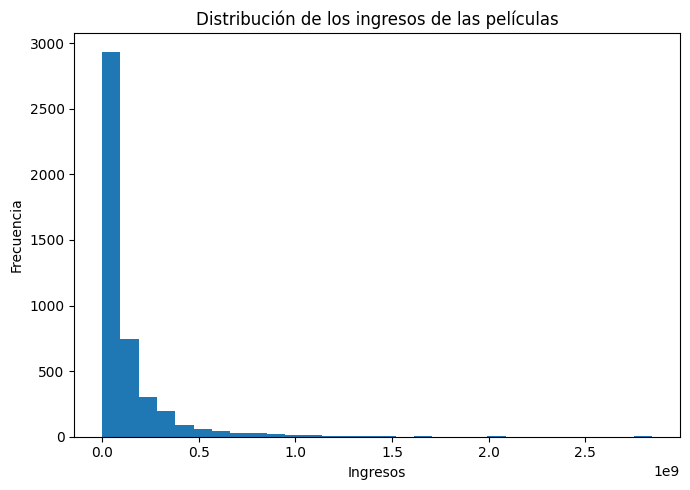

In [80]:

plt.figure(figsize=(7, 5))
plt.hist(df_presupuesto_ingresos["revenue"], bins=30)
plt.xlabel("Ingresos")
plt.ylabel("Frecuencia")
plt.title("Distribución de los ingresos de las películas")
plt.tight_layout()
plt.show()


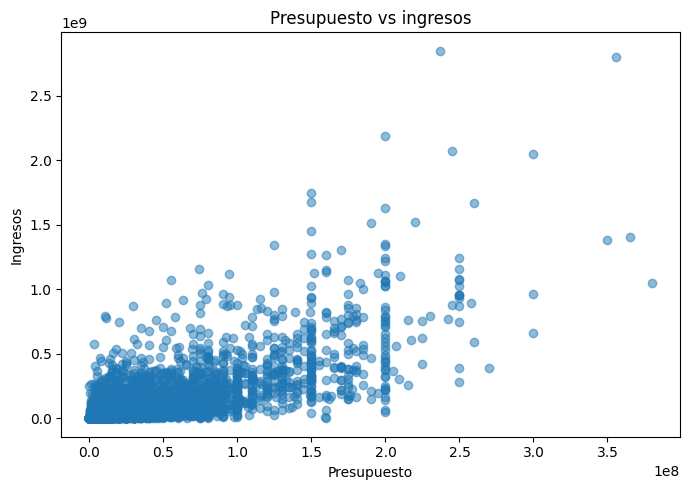

In [81]:

plt.figure(figsize=(7, 5))
plt.scatter(
    df_presupuesto_ingresos["budget"],
    df_presupuesto_ingresos["revenue"],
    alpha=0.5
)
plt.xlabel("Presupuesto")
plt.ylabel("Ingresos")
plt.title("Presupuesto vs ingresos")
plt.tight_layout()
plt.show()


In [82]:
#4.12 y 4.13

df_mes_ingresos = df[df["revenue"] > 0].copy()
df_mes_ingresos["releaseMonth"] = df_mes_ingresos["releaseDate"].dt.month

ingresos_por_mes = df_mes_ingresos.groupby("releaseMonth")["revenue"].mean()
ingresos_por_mes


releaseMonth
1     6.040760e+07
2     8.276857e+07
3     9.710837e+07
4     1.022529e+08
5     1.652726e+08
6     1.658074e+08
7     1.327641e+08
8     7.077733e+07
9     6.033503e+07
10    8.514863e+07
11    1.278116e+08
12    1.244115e+08
Name: revenue, dtype: float64

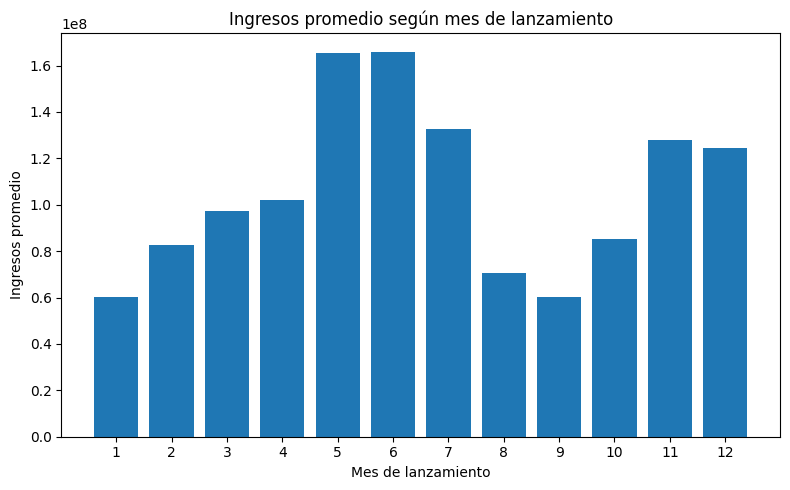

(np.int32(6), np.float64(165807439.39529914))

In [83]:

plt.figure(figsize=(8, 5))
plt.bar(ingresos_por_mes.index, ingresos_por_mes.values)
plt.xlabel("Mes de lanzamiento")
plt.ylabel("Ingresos promedio")
plt.title("Ingresos promedio según mes de lanzamiento")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

ingresos_por_mes.idxmax(), ingresos_por_mes.max()



In [84]:

# 4.14
corr_voto_ingresos = (
    df[(df["revenue"] > 0) & (df["voteCount"] > 0)]
    [["voteAvg", "revenue"]]
    .corr()
    .iloc[0, 1]
)

corr_voto_ingresos


np.float64(0.1530355847433901)

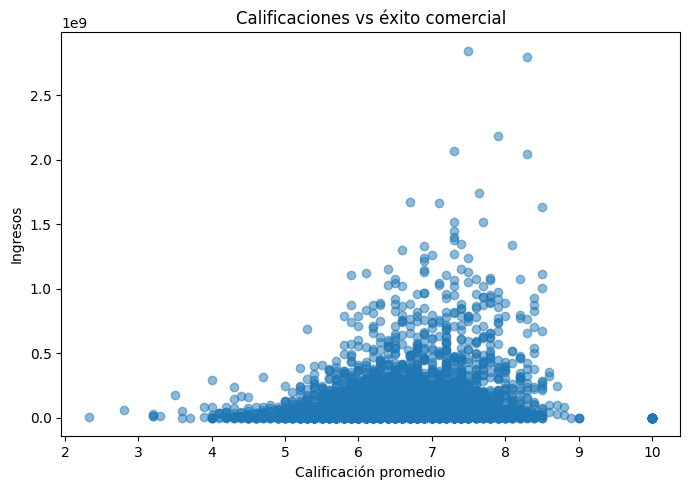

In [85]:

plt.figure(figsize=(7, 5))
plt.scatter(
    df[(df["revenue"] > 0) & (df["voteCount"] > 0)]["voteAvg"],
    df[(df["revenue"] > 0) & (df["voteCount"] > 0)]["revenue"],
    alpha=0.5
)
plt.xlabel("Calificación promedio")
plt.ylabel("Ingresos")
plt.title("Calificaciones vs éxito comercial")
plt.tight_layout()
plt.show()


In [89]:
# 4.15
df_marketing = df[df["revenue"] > 0].copy()

df_marketing["has_homepage"] = df_marketing["homePage"].notna()
df_marketing.groupby("has_homepage")["revenue"].mean()



has_homepage
False    6.641026e+07
True     1.506588e+08
Name: revenue, dtype: float64

In [93]:

df_marketing.groupby("video")["revenue"].mean()



video
False    9.412216e+07
True     1.063250e+07
Name: revenue, dtype: float64

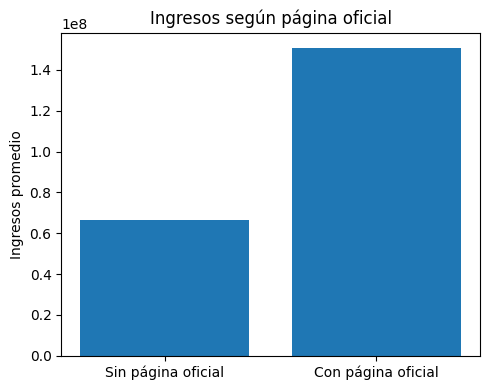

In [92]:

plt.figure(figsize=(5, 4))
plt.bar(
    ["Sin página oficial", "Con página oficial"],
    df_marketing.groupby("has_homepage")["revenue"].mean().values
)
plt.ylabel("Ingresos promedio")
plt.title("Ingresos según página oficial")
plt.tight_layout()
plt.show()

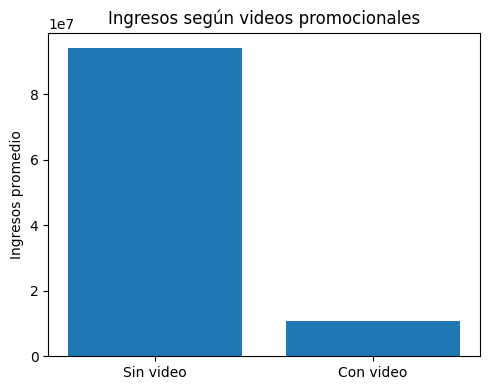

In [94]:

plt.figure(figsize=(5, 4))
plt.bar(
    ["Sin video", "Con video"],
    df_marketing.groupby("video")["revenue"].mean().values
)
plt.ylabel("Ingresos promedio")
plt.title("Ingresos según videos promocionales")
plt.tight_layout()
plt.show()
